# Dokumentacja Projektu: Analiza Ruchu Rowerowego w Chicago

## Wstęp
Niniejszy projekt ma na celu zbudowanie kompletnego potoku przetwarzania danych (Data Pipeline) w celu przewidywania natężenia ruchu rowerowego w systemie miejskim Chicago. Projekt wykorzystuje historyczne dane wypożyczeń, które są wzbogacane o dane kalendarzowe (święta państwowe) oraz dane meteorologiczne.

---

## Etap 1: Akwizycja i wstępne przetwarzanie danych (`01.py`)

**Cel etapu:**
Automatyzacja procesu pozyskiwania zbiorów danych surowych z platformy Kaggle oraz przygotowanie lokalnego środowiska pracy. Skrypt odpowiada za stworzenie struktury katalogów, konsolidację kilkudziesięciu plików CSV do jednego zbioru oraz redukcję wymiarowości (usunięcie zbędnego szumu informacyjnego). Wynik jest zapisywany w formacie Parquet, co optymalizuje wydajność kolejnych operacji wejścia/wyjścia.

### Sekcja 1.1: Pobieranie danych i organizacja plików
Ten fragment kodu łączy się z API Kaggle, pobiera zbiór danych do pamięci podręcznej systemu, a następnie bezpiecznie przenosi go do struktury katalogów naszego projektu.

In [2]:
import kagglehub
import os
import shutil

# 1. Definicja docelowej ścieżki projektu
target_dir = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\dane_kaggle"

# 2. Pobieranie zbioru (pobierze do domyślnej pamięci podręcznej)
downloaded_path = kagglehub.dataset_download("gunnarn/chicago-bicycle-rent-usage")

# 3. Tworzenie folderu w projekcie, jeśli nie istnieje
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    print(f"Utworzono folder: {target_dir}")

# 4. Przenoszenie zawartości do Twojego projektu
for item in os.listdir(downloaded_path):
    s = os.path.join(downloaded_path, item)
    d = os.path.join(target_dir, item)

    if os.path.isdir(s):
        if os.path.exists(d):
            shutil.rmtree(d)
        shutil.copytree(s, d)
    else:
        shutil.copy2(s, d)

print(f"Pliki zostały zapisane w: {target_dir}")

Pliki zostały zapisane w: C:\zrodla_i_reprezentacja_danych\Wersja_finalna\dane_kaggle


### Analiza kodu: Sekcja 1.1
* **Biblioteki:** * `kagglehub`: Służy do automatycznego uwierzytelniania i pobierania datasetów z Kaggle.
  * `os`: Umożliwia operacje na ścieżkach systemowych (`os.path.join`) i sprawdzanie istnienia folderów (`os.path.exists`).
  * `shutil`: Pozwala na wysokopoziomowe operacje na plikach, w tym kopiowanie całych drzew katalogów (`copytree`) lub pojedynczych plików (`copy2`).
* **Zmienne:** `target_dir` (ścieżka docelowa w naszym środowisku) oraz `downloaded_path` (ścieżka do plików pobranych w pamięci cache Kagglehub).

---

### Sekcja 1.2: Konsolidacja plików CSV
Pobrany dataset składa się z wielu oddzielnych plików. Ta sekcja ładuje wszystkie pliki CSV do pamięci operacyjnej i łączy je w jedną, spójną tabelę danych.

In [3]:
import pandas as pd
import glob

# 1. Ustawienie ścieżki do folderu z danymi
path = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\dane_kaggle"

# 2. Pobranie listy wszystkich plików CSV
all_files = glob.glob(os.path.join(path, "*.csv"))
print(f"Znaleziono {len(all_files)} plików do połączenia.")

# 3. Wczytywanie plików i łączenie ich w jeden DataFrame
df_list = []
for filename in all_files:
    # Wymuszamy typ 'object' (string) podczas wczytywania
    temp_df = pd.read_csv(filename, dtype={'start_station_id': str, 'end_station_id': str})
    df_list.append(temp_df)
    print(f"Wczytano: {os.path.basename(filename)} | Wierszy: {len(temp_df)}")

# Łączenie wszystkich tabel w jedną
full_df = pd.concat(df_list, axis=0, ignore_index=True)
print("-" * 30)
print(f"Sukces! Połączony zbiór ma {len(full_df)} wierszy.")

# Upewniamy się, że całe kolumny są traktowane jako tekst (string)
full_df['start_station_id'] = full_df['start_station_id'].astype(str)
full_df['end_station_id'] = full_df['end_station_id'].astype(str)

# 4. Definicja ścieżki i zapis do pliku Parquet
output_path = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_01_polaczone_dane_rowerowe.parquet"
full_df.to_parquet(output_path, index=False)

print(f"Plik został pomyślnie zapisany w: {output_path}")

Znaleziono 28 plików do połączenia.
Wczytano: 202004-divvy-tripdata.csv | Wierszy: 84776
Wczytano: 202005-divvy-tripdata.csv | Wierszy: 200274
Wczytano: 202006-divvy-tripdata.csv | Wierszy: 343005
Wczytano: 202007-divvy-tripdata.csv | Wierszy: 551480
Wczytano: 202008-divvy-tripdata.csv | Wierszy: 622361
Wczytano: 202009-divvy-tripdata.csv | Wierszy: 532958
Wczytano: 202010-divvy-tripdata.csv | Wierszy: 388653
Wczytano: 202011-divvy-tripdata.csv | Wierszy: 259716
Wczytano: 202012-divvy-tripdata.csv | Wierszy: 131573
Wczytano: 202101-divvy-tripdata.csv | Wierszy: 96834
Wczytano: 202102-divvy-tripdata.csv | Wierszy: 49622
Wczytano: 202103-divvy-tripdata.csv | Wierszy: 228496
Wczytano: 202104-divvy-tripdata.csv | Wierszy: 337230
Wczytano: 202105-divvy-tripdata.csv | Wierszy: 531633
Wczytano: 202106-divvy-tripdata.csv | Wierszy: 729595
Wczytano: 202107-divvy-tripdata.csv | Wierszy: 822410
Wczytano: 202108-divvy-tripdata.csv | Wierszy: 804352
Wczytano: 202109-divvy-tripdata.csv | Wierszy: 75

### Analiza kodu: Sekcja 1.2
* **Biblioteki:** * `pandas`: Standard przemysłowy w Pythonie do operacji na danych tabelarycznych (struktury DataFrame).
  * `glob`: Moduł służący do wyszukiwania ścieżek do plików za pomocą wzorców (w tym przypadku `*.csv`).
* **Logika algorytmu:** * Algorytm korzysta ze standardowego wzorca agregacji: tworzy pustą listę `df_list`, wewnątrz pętli `for` dopisuje do niej kolejne wczytywane pliki (zmienna `temp_df`), a po zakończeniu pętli łączy wszystko instrukcją `pd.concat(..., ignore_index=True)`.
* **Przetwarzanie danych i wymuszanie typów:** Kluczowym elementem inżynierskim jest przekazanie parametru `dtype` wewnątrz `pd.read_csv`. Identyfikatory stacji (`start_station_id`) czasami składają się z samych cyfr, a czasami zawierają litery. Narzucenie parserowi typu `str` (tekstowego) zapobiega usunięciu zer wiodących i błędom kompatybilności podczas łączenia tabel (zapobiega to mieszaniu typów float/int z obiektowymi).
* **Wyjście:** Plik pośredni `_01_polaczone_dane_rowerowe.parquet`. Parquet jest kolumnowym formatem zapisu, wysoce kompresującym dane, co pozwala na szybsze ładowanie tabeli w następnych etapach w porównaniu do standardowego formatu CSV.

---

### Sekcja 1.3: Redukcja wymiarowości (Oczyszczanie zbioru)
Surowe dane zawierają informacje takie jak współrzędne geograficzne czy ID pojedynczych przejazdów. Ponieważ celem jest prognoza *ogólnego*, dziennego natężenia ruchu, atrybuty jednostkowe są redukowane.

In [4]:
# Lista kolumn przeznaczonych do odrzucenia (redukcja wymiarowości)
columns_to_drop = [
    'ride_id', 'rideable_type', 'ended_at',
    'start_station_name', 'start_station_id',
    'end_station_name', 'end_station_id',
    'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual'
]

# Mechanizm bezpieczeństwa: sprawdzamy, które z tych kolumn faktycznie są w tabeli
existing_cols_to_drop = [col for col in columns_to_drop if col in full_df.columns]

# Usuwamy kolumny (inplace=True nadpisuje obecną tabelę w pamięci RAM)
full_df.drop(columns=existing_cols_to_drop, inplace=True)

print(f"Usunięto niepotrzebne kolumny. Zostały {len(full_df.columns)} kolumny.")
print(f"Zatrzymane kolumny: {list(full_df.columns)}")
print("-" * 30)

# 5. ZAPIS odchudzonego zbioru do nowego pliku
output_path = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_02_usuniete_dane_rowerowe.parquet"
full_df.to_parquet(output_path, index=False)

print("-" * 50)

Usunięto niepotrzebne kolumny. Zostały 1 kolumny.
Zatrzymane kolumny: ['started_at']
------------------------------
--------------------------------------------------


### Analiza kodu: Sekcja 1.3
* **Przetwarzanie danych:** W liście `columns_to_drop` zadeklarowano kolumny do usunięcia. Należą do nich unikalne identyfikatory (`ride_id`) oraz dokładne współrzędne geograficzne (`start_lat`, `end_lat` itp.).
* **Wyrażenie składane (List Comprehension) i zabezpieczenie:** Konstrukcja `[col for col in columns_to_drop if col in full_df.columns]` to przykład *programowania defensywnego*. Zbiory danych (np. z serwisu Kaggle) często ulegają aktualizacjom, w których mogą zniknąć pewne kolumny. Ta linijka zapewnia, że metoda `drop` spróbuje usunąć tylko te atrybuty, które fizycznie istnieją w pamięci – unikając w ten sposób krytycznego błędu `KeyError` przerywającego skrypt.
* **Metoda `.drop` z parametrem `inplace=True`:** Oszczędza zasoby komputera, ponieważ modyfikuje zbiór danych bezpośrednio w jego oryginalnym miejscu w pamięci RAM, bez tworzenia i alokowania pamięci na nową kopię struktury `DataFrame`.
* **Wyjście:** Plik `_02_usuniete_dane_rowerowe.parquet` to fundamentalny fundament do kolejnych etapów agregacji – zawiera tylko czas rozpoczęcia wypożyczeń.

## Etap 2: Weryfikacja spójności i profilowanie danych (`02.py`)

**Cel etapu:**
Głównym zadaniem tego modułu jest przeprowadzenie podstawowej analizy eksploracyjnej na poziomie meta-danych (tzw. *sanity check*). Po wykonaniu łączenia wielu plików CSV i redukcji wymiarowości w Etapie 1, należy bezwzględnie zweryfikować fizyczną integralność wygenerowanego pliku Parquet. Skrypt odczytuje odchudzony zbiór, a następnie profiluje jego ramy czasowe oraz całkowity wolumen, upewniając się, że dane pokrywają oczekiwany zakres badawczy.

In [5]:
#---------------------------------------------------------------------------------------4
import pandas as pd

# 1. Ścieżka do pliku z usuniętymi kolumnami
input_path = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_02_usuniete_dane_rowerowe.parquet"

# 2. Wczytanie danych
df = pd.read_parquet(input_path)

# 3. Konwersja na format datetime (żeby operacje na datach były precyzyjne)
df['started_at'] = pd.to_datetime(df['started_at'])

# 4. Wyznaczenie pierwszego i ostatniego dnia
pierwszy_przejazd = df['started_at'].min()
ostatni_przejazd = df['started_at'].max()

# 5. Sprawdzenie liczby wierszy
liczba_wierszy = len(df)

# 6. Wyświetlenie wyników
print(f"Pierwszy zarejestrowany przejazd: {pierwszy_przejazd}")
print(f"Ostatni zarejestrowany przejazd:  {ostatni_przejazd}")
print(f"Całkowita liczba przejazdów (wierszy): {liczba_wierszy:,}".replace(',', ' '))

Pierwszy zarejestrowany przejazd: 2020-04-01 00:00:30
Ostatni zarejestrowany przejazd:  2022-07-31 23:59:58
Całkowita liczba przejazdów (wierszy): 11 812 079


## Etap 3: Inżynieria cech – Dni Świąteczne (`03.py`)

**Cel etapu:** Pozyskanie kalendarza świąt dla stanu Illinois za pomocą techniki Web Scraping w celu uwzględnienia dni wolnych od pracy, które mają istotny wpływ na natężenie ruchu rowerowego.

In [6]:
# ---------------------------------------------------------------------------------------5
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime

lata = [2020, 2021, 2022]
swieta_lista = []

naglowki = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

for rok in lata:
    url = f"https://www.officeholidays.com/countries/usa/illinois/{rok}"

    response = requests.get(url, headers=naglowki)

    if response.status_code == 200:
        soup = BeautifulSoup(response.content, 'html.parser')

        tabela = soup.find('table', class_='country-table')

        if tabela:
            wiersze = tabela.find('tbody').find_all('tr')

            for wiersz in wiersze:
                czas_tag = wiersz.find('time')

                komorki = wiersz.find_all('td')

                if czas_tag and czas_tag.has_attr('datetime') and len(komorki) >= 3:
                    data_str = czas_tag['datetime']

                    nazwa_swieta = komorki[2].text.strip()

                    data_obj = datetime.strptime(data_str, "%Y-%m-%d").date()

                    swieta_lista.append({
                        'date': data_obj,
                        'holiday_name': nazwa_swieta,
                        'is_holiday': 1
                    })
    else:
        print(f"Błąd! Serwer odrzucił połączenie dla roku {rok}. Kod: {response.status_code}")

df_swieta = pd.DataFrame(swieta_lista)

df_swieta = df_swieta.drop_duplicates(subset=['date'])

df_swieta['date'] = pd.to_datetime(df_swieta['date'])

output_path = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_03_swieta_chicago.parquet"
df_swieta.to_parquet(output_path, index=False)

### Analiza techniczna (Etap 3)
* **Biblioteki:** `requests` (obsługa żądań HTTP), `BeautifulSoup` (parsowanie kodu HTML), `pandas`, `datetime`.
* **Logika programu:** Pętla `for` iteruje po zadeklarowanych latach. Program wysyła żądanie GET z uwierzytelniającym nagłówkiem `User-Agent`. Po otrzymaniu statusu 200 (OK), BeautifulSoup wyszukuje tabelę (`country-table`), a w niej wiersze i znaczniki `<time>`.
* **Przetwarzanie danych:** Ekstrakcja daty i nazwy święta do słownika wraz z flagą binarną `is_holiday: 1`. Lista słowników jest konwertowana na DataFrame.
* **Czyszczenie:** Funkcja `drop_duplicates` zapobiega powieleniom, a kolumna `date` jest rzutowana na typ `datetime`.
* **Zależności i I/O:** Skrypt działa niezależnie od poprzednich. Wyjściem jest plik Parquet ze słownikiem dni świątecznych.

---

## Etap 4: Akwizycja i imputacja danych pogodowych (`04.py`)

**Cel etapu:** Pozyskanie historycznych danych meteorologicznych przez publiczne API w celu powiązania warunków atmosferycznych z zachowaniami rowerzystów.

In [8]:
import pandas as pd
from datetime import datetime
from meteostat import daily


start_date = datetime(2020, 4, 1)
end_date = datetime(2022, 7, 31)

chicago_station = '72530'

data = daily(chicago_station, start_date, end_date)
weather_df = data.fetch()

if weather_df is None or weather_df.empty:
    print("BŁĄD: API nie zwróciło danych! Sprawdź połączenie sieciowe.")
else:
    weather_df = weather_df.reset_index()

    # 1. Wybieramy TYLKO te kolumny, które na pewno dostarcza to API
    weather_df = weather_df[['time', 'tmin', 'tmax', 'prcp']]

    # 2. Tworzymy własną kolumnę 'tavg' (średnia temperatura)
    weather_df['tavg'] = ((weather_df['tmin'] + weather_df['tmax']) / 2).round(2)

    # Zmieniamy nazwę 'time' na 'date'
    weather_df.rename(columns={'time': 'date'}, inplace=True)

    # Konwersja na format daty
    weather_df['date'] = pd.to_datetime(weather_df['date']).dt.date

    # Uzupełnianie ewentualnych braków danych
    weather_df['prcp'] = weather_df['prcp'].fillna(0)
    weather_df['tmin'] = weather_df['tmin'].ffill()
    weather_df['tmax'] = weather_df['tmax'].ffill()

    weather_df['tavg'] = weather_df['tavg'].fillna(((weather_df['tmin'] + weather_df['tmax']) / 2).round(2))

    output_path = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_04_pogoda_chicago.parquet"
    weather_df.to_parquet(output_path, index=False)

### Analiza techniczna (Etap 4)
* **Biblioteki:** `meteostat` (zewnętrzne API dla danych stacji WMO), `pandas`, `datetime`.
* **Logika programu:** Pobranie dziennych wskazań stacji referencyjnej `72530` w Chicago. Odrzucenie zbędnych cech z API.
* **Operacje matematyczne i imputacja danych:** * Utworzenie zmiennej średniej temperatury `tavg` ze wzoru $(T_{min} + T_{max}) / 2$.
  * Obsługa braków danych (szumu): `fillna(0)` dla opadów `prcp` (brak rejestracji oznacza brak deszczu), `ffill()` dla temperatur (przepisanie ostatniej poprawnej wartości pozwala uniknąć skrajnych wahań).
* **Zależności i I/O:** Moduł niezależny. Wyjściem jest plik Parquet z danymi pogodowymi dla każdego dnia badanego przedziału.

---

## Etap 5: Fuzja danych, OHE i standaryzacja (`05.py`)

**Cel etapu:** Skonsolidowanie niezależnych źródeł (rowery, święta, pogoda) w jedną Master Tabelę, agregacja danych transakcyjnych do poziomu dziennego oraz wektoryzacja na potrzeby modelu ML.

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("Łączenie danych i przygotowanie do modelu...")

# 1. Wczytanie plików
df_rowery = pd.read_parquet(r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_02_usuniete_dane_rowerowe.parquet")
df_swieta = pd.read_parquet(r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_03_swieta_chicago.parquet")
df_pogoda = pd.read_parquet(r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_04_pogoda_chicago.parquet")

# 2. Agregacja rowerów + wyciągnięcie dnia tygodnia
df_rowery['date'] = pd.to_datetime(df_rowery['started_at']).dt.date
df_zagregowane = df_rowery.groupby('date').size().reset_index(name='total_rides')
df_zagregowane['day_of_week'] = pd.to_datetime(df_zagregowane['date']).dt.day_name()

# 3. Ujednolicenie formatów dat
df_zagregowane['date'] = pd.to_datetime(df_zagregowane['date'])
df_swieta['date'] = pd.to_datetime(df_swieta['date'])
df_pogoda['date'] = pd.to_datetime(df_pogoda['date'])

# 4. Łączenie
master_df = pd.merge(df_zagregowane, df_pogoda, on='date', how='inner')
master_df = pd.merge(master_df, df_swieta, on='date', how='left')

# 5. Czyszczenie świąt
master_df['is_holiday'] = master_df['is_holiday'].fillna(0).astype(int)
master_df.drop(columns=['holiday_name'], inplace=True)

# 6. One Hot Encoding (dni tygodnia)
master_df = pd.get_dummies(master_df, columns=['day_of_week'], drop_first=True)

# 7. Standaryzacja
scaler = StandardScaler()
kolumny_numeryczne = ['tavg', 'tmin', 'tmax', 'prcp']
master_df[kolumny_numeryczne] = scaler.fit_transform(master_df[kolumny_numeryczne])

# 8. Zapis finalny
master_df.drop(columns=['date'], inplace=True) # Model nie czyta dat
master_df.to_parquet(r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_05_FINAL_dane_znormalizowane.parquet", index=False)

Łączenie danych i przygotowanie do modelu...


### Analiza techniczna (Etap 5)
* **Biblioteki:** `pandas`, `sklearn.preprocessing.StandardScaler` (skalowanie rozkładów).
* **Agregacja:** Funkcja `groupby('date').size()` transformuje kilkumilionowy zbiór jednostkowych przejazdów na dobowy zbiór zagregowany ze zliczonym atrybutem `total_rides`. Funkcja `.dt.day_name()` ekstrahuje nazwę dnia z daty.
* **Łączenie (Merge):** Algorytm używa złączeń relacyjnych (`inner join` dla pogody, zapewniając pełną kompletność danych, oraz `left join` dla świąt, przypisując cechę tylko w konkretnych dniach). Połączenia następują na kluczu `date`.
* **Zmienne kategoryczne (OHE):** `pd.get_dummies` zamienia nazwy dni tygodnia na binarną macierz z usunięciem pierwszej zmiennej (`drop_first=True`) w celu redukcji współliniowości cech (multicollinearity).
* **Standaryzacja:** Parametry pogodowe są skalowane do postaci $z = (x - \mu) / \sigma$. Normalizuje to jednostki (stopnie i milimetry), optymalizując zbieżność algorytmiczną modeli ML.

---

## Etap 6: Trenowanie modelu XGBoost i ewaluacja (`06.py`)

**Cel etapu:** Implementacja, ewaluacja oraz inspekcja ważności cech (Feature Importance) za pomocą modelu regresji gradientowej (XGBoost).

------------------------------
WYNIKI MODELU XGBOOST:
Średni błąd (MAE): 3824.29
Współczynnik R2: 0.67
------------------------------


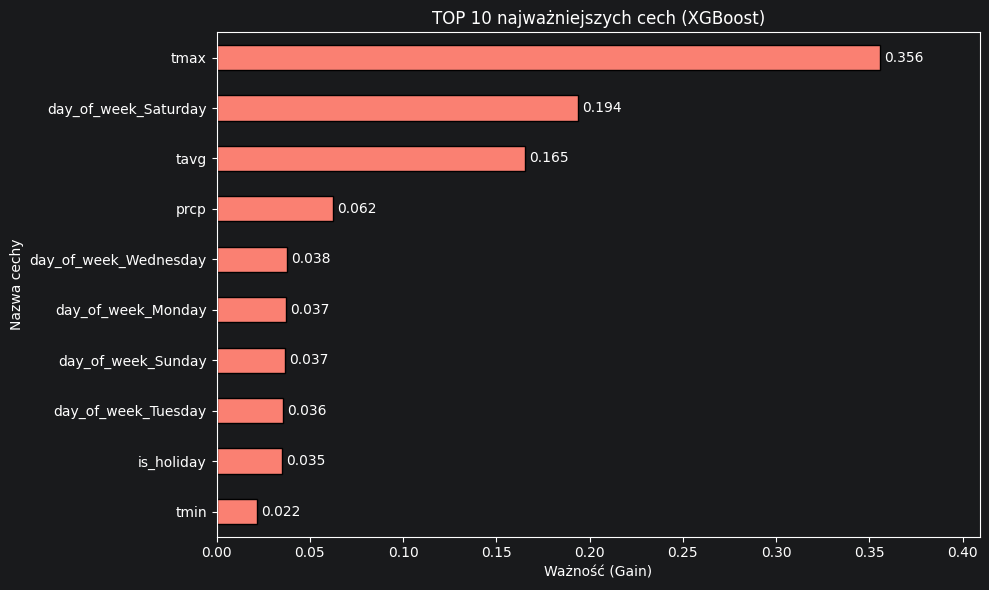

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

input_path = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_05_FINAL_dane_znormalizowane.parquet"
df = pd.read_parquet(input_path)

X = df.drop(columns=['total_rides'])
y = df['total_rides']

# Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicjalizacja i trening modelu XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, objective='reg:squarederror')
model.fit(X_train, y_train)

# Predykcja
predictions = model.predict(X_test)

# Wyniki
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("-" * 30)
print("WYNIKI MODELU XGBOOST:")
print(f"Średni błąd (MAE): {mae:.2f}")
print(f"Współczynnik R2: {r2:.2f}")
print("-" * 30)

# Wizualizacja TOP 10 najważniejszych cech
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_10 = feature_importances.sort_values(ascending=True).tail(10)

# Rysujemy wykres
plt.figure(figsize=(10, 6))

ax = top_10.plot(kind='barh', color='salmon', edgecolor='black')

ax.bar_label(ax.containers[0], fmt='%.3f', padding=3)

ax.set_xlim(right=top_10.max() * 1.15)

plt.title('TOP 10 najważniejszych cech (XGBoost)')
plt.xlabel('Ważność (Gain)')
plt.ylabel('Nazwa cechy')

plt.tight_layout()

plt.savefig("__wykres_waznosci_xgboost.png")
plt.show()

### Analiza techniczna (Etap 6)
* **Biblioteki:** `xgboost` (zaawansowany algorytm Ensemble Learning oparty o boosting drzew), zbiór narzędzi ze `sklearn` (podział danych, metryki MAE/R2) oraz `matplotlib` do wizualizacji.
* **Podział danych:** Zastosowanie konwencji Pareto: 80% obserwacji stanowi zbiór uczący, 20% to zbiór ewaluacyjny. Seed (`random_state=42`) zapewnia determinizm wyniku.
* **Uczenie maszyny:** Trenowanie modelu `XGBRegressor` w celu minimalizacji błędu średniokwadratowego (`objective='reg:squarederror'`). Algorytm koryguje wagi predykcyjne z krokiem uczenia 0.1 przez 100 estymatorów.
* **Metryki błędu:** Model generuje wyniki predykcyjne wektora `y_test`, po czym wylicza Mean Absolute Error (bezwzględne odchylenie w sztukach rowerów) oraz R2 Score (procent wyjaśnianej wariancji).
* **Zrozumienie modelu:** Wydobycie cechy `.feature_importances_` (opartej o metrykę matematyczną Gain), sortowanie oraz graficzna reprezentacja wykresu słupkowego za pomocą `matplotlib`.

---

## Etap 7: Wizualizacja zależności fizycznych (`07.py`)

**Cel etapu:** Skorelowanie rzeczywistych danych środowiskowych ze zmienną objaśnianą (liczbą wypożyczeń) z wykorzystaniem grafiki statystycznej.

Wykres temperatury zapisany jako: wykres_wplyw_temperatury.png
Wykres opadów zapisany jako: wykres_wplyw_opadow.png


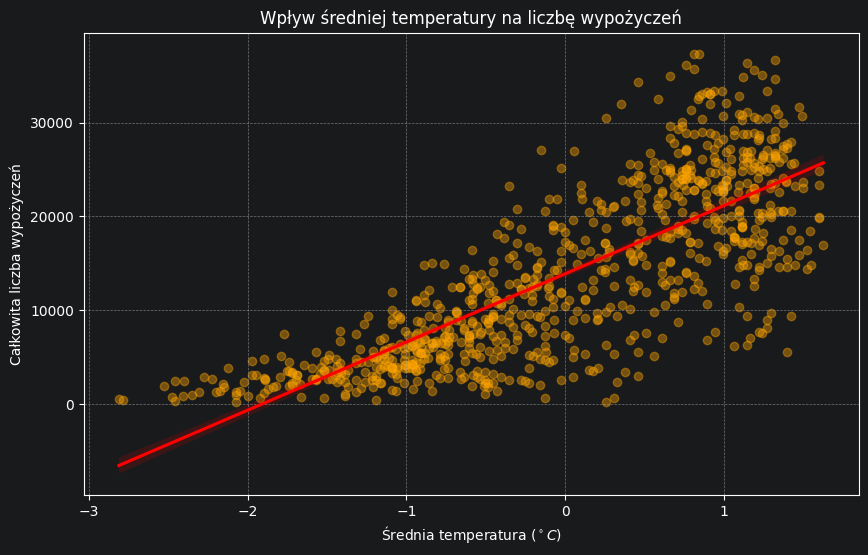

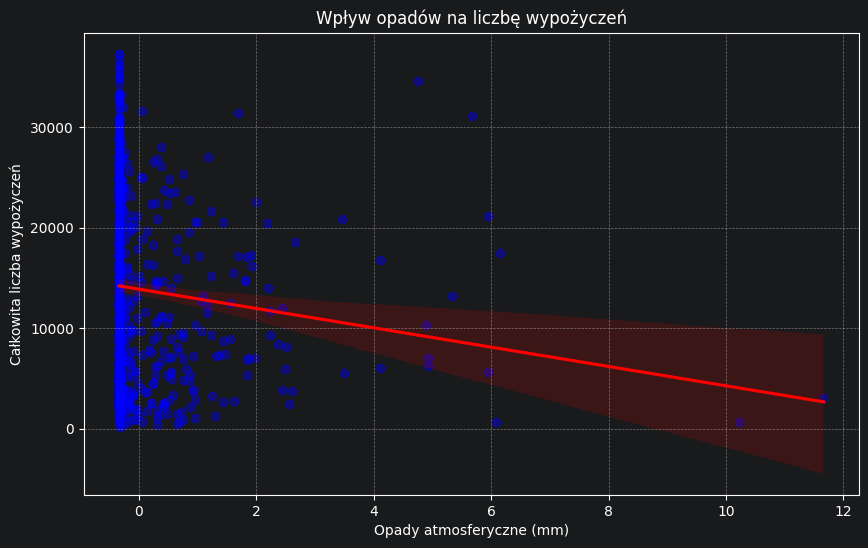

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_path = r"C:\zrodla_i_reprezentacja_danych\Wersja_finalna\_05_FINAL_dane_znormalizowane.parquet"
df = pd.read_parquet(input_path)

df['tavg'] = pd.to_numeric(df['tavg'])
df['prcp'] = pd.to_numeric(df['prcp'])
df['total_rides'] = pd.to_numeric(df['total_rides'])

# 2. Wykres wpływu średniej temperatury (tavg)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='tavg', y='total_rides',
            scatter_kws={'alpha':0.4, 'color':'orange'},
            line_kws={'color':'red'})
plt.title('Wpływ średniej temperatury na liczbę wypożyczeń')
plt.xlabel(r'Średnia temperatura ($^\circ C$)')
plt.ylabel('Całkowita liczba wypożyczeń')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("__wykres_wplyw_temperatury.png")
print("Wykres temperatury zapisany jako: wykres_wplyw_temperatury.png")

# 3. Wykres wpływu opadów (prcp)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='prcp', y='total_rides',
            scatter_kws={'alpha':0.4, 'color':'blue'},
            line_kws={'color':'red'})
plt.title('Wpływ opadów na liczbę wypożyczeń')
plt.xlabel('Opady atmosferyczne (mm)')
plt.ylabel('Całkowita liczba wypożyczeń')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("__wykres_wplyw_opadow.png")
print("Wykres opadów zapisany jako: wykres_wplyw_opadow.png")

### Analiza techniczna (Etap 7)
* **Biblioteki:** `seaborn` – środowisko zbudowane na szczycie `matplotlib`, służące do zaawansowanej i estetycznej wizualizacji danych statystycznych.
* **Przetwarzanie graficzne:** Użycie instrukcji `sns.regplot()` generuje wykresy punktowe nałożone na linie regresji liniowej z wyliczonym matematycznie przedziałem ufności. Moduł udowadnia siłę natury korelacji (np. dodatnia dla temperatury, ujemna dla opadów).

---

## Podsumowanie działania całego projektu

Całość przedsięwzięcia składa się na kompletny, w pełni zautomatyzowany cykl inżynierii danych i modelowania predykcyjnego (ETL -> ML):
1. **Ekstrakcja (E):** Pobrano dane surowe z Kaggle, ujednolicono je oraz wzbogacono bazę poprzez wykonanie web scrapingu kalendarza świąt państwowych i podłączenie się do globalnego API stacji meteorologicznych.
2. **Transformacja (T):** Zredukowano szum przestrzenny w danych pierwotnych, zagregowano bazę do reprezentacji dziennej i wykonano procesy czyszczenia danych: radzenie sobie z brakami (ffill/fillna) oraz skalowanie przestrzeni wektorowej i kategoryzację dni tygodnia (One Hot Encoding).
3. **Modelowanie (M):** Utworzono zaawansowany model drzewiasty (XGBoost) klasyfikujący wpływ czynników na dobowe wypożyczenia wraz z ich walidacją matematyczną i wizualizacją wpływu cech (Explainable AI).
